In [4]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")


In [7]:
df = pd.read_csv("train.csv")
df.head()


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


In [8]:
df.shape


(5847, 14)

In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5847 entries, 0 to 5846
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         5847 non-null   int64  
 1   Name               5847 non-null   str    
 2   Location           5847 non-null   str    
 3   Year               5847 non-null   int64  
 4   Kilometers_Driven  5847 non-null   int64  
 5   Fuel_Type          5847 non-null   str    
 6   Transmission       5847 non-null   str    
 7   Owner_Type         5847 non-null   str    
 8   Mileage            5845 non-null   str    
 9   Engine             5811 non-null   str    
 10  Power              5811 non-null   str    
 11  Seats              5809 non-null   float64
 12  New_Price          815 non-null    str    
 13  Price              5847 non-null   float64
dtypes: float64(2), int64(3), str(9)
memory usage: 639.6 KB


In [10]:
df.describe(include="all")


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
count,5847.000000,5847,5847,5847.000000,5.847000e+03,5847,5847,5847,5845,5811,5811,5809.000000,815,5847.000000
unique,NaN,1804,11,NaN,NaN,3,2,4,419,140,361,NaN,534,NaN
top,NaN,Mahindra XUV500 W8 2WD,Mumbai,NaN,NaN,Diesel,Manual,First,18.9 kmpl,1197 CC,74 bhp,NaN,95.13 Lakh,NaN
freq,NaN,49,762,NaN,NaN,3161,4135,4811,172,602,235,NaN,6,NaN
mean,3013.181461,NaN,NaN,2013.448435,5.841013e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.286452,NaN,9.653742
std,1736.398890,NaN,NaN,3.194949,9.237971e+04,NaN,NaN,NaN,NaN,NaN,NaN,0.806668,NaN,11.275966
min,1.000000,NaN,NaN,1998.000000,1.710000e+02,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,0.440000
25%,1509.500000,NaN,NaN,2012.000000,3.346750e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,3.550000
50%,3015.000000,NaN,NaN,2014.000000,5.257600e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,5.750000
75%,4517.500000,NaN,NaN,2016.000000,7.249050e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,10.250000


In [11]:
# Drop the unnecessary index column
df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


In [12]:
df.isnull().sum()


Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  38
New_Price            5032
Price                   0
dtype: int64

In [13]:
df.duplicated().sum()


np.int64(0)

In [17]:
# Remove duplicates if any
df = df.drop_duplicates()



In [18]:
# Clean Mileage (e.g., "19.67 kmpl" -> 19.67)
df["Mileage"] = df["Mileage"].str.extract("(\d+\.?\d*)").astype(float)

# Clean Engine (e.g., "1582 CC" -> 1582)
df["Engine"] = df["Engine"].str.extract("(\d+)").astype(float)

# Clean Power (e.g., "126.2 bhp" -> 126.2)
df["Power"] = df["Power"].str.extract("(\d+\.?\d*)").astype(float)

# Clean New_Price (e.g., "8.61 Lakh" -> 8.61)
df["New_Price"] = df["New_Price"].str.extract("(\d+\.?\d*)").astype(float)

df.head()


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,NaN,12.50
1,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13.00,1199.0,88.70,5.0,8.61,4.50
2,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,NaN,6.00
3,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,NaN,17.74
4,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,NaN,3.50


In [19]:
df.isnull().sum()


Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  38
New_Price            5032
Price                   0
dtype: int64

In [37]:
# Get numeric and categorical columns safely
numeric_cols = df.select_dtypes(include=[np.number]).columns # Get numeric columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns # Get categorical columns

# Fill numeric columns with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check again
df.isnull().sum()

# print(df.to_string())



Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
New_Price            0
Price                0
dtype: int64

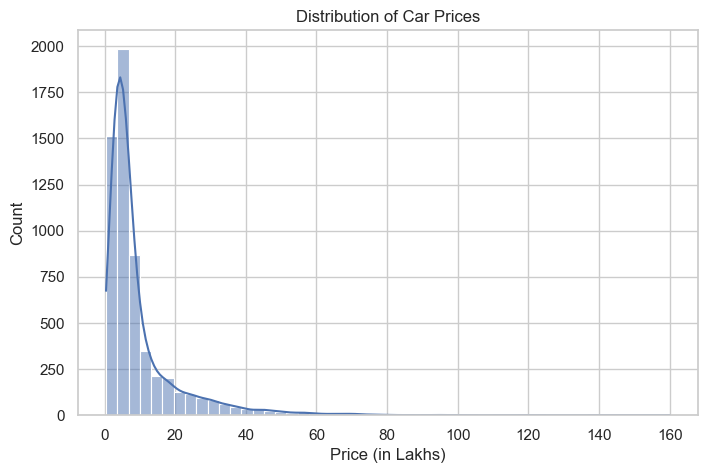

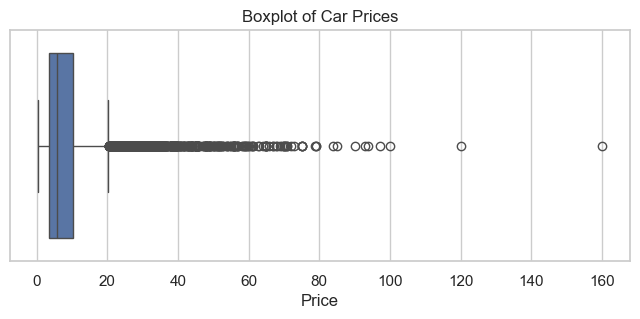

In [ ]:
# Price Distribution
plt.figure(figsize=(8,5)) # Adjust the figure size for better visibility
sns.histplot(df["Price"], bins=50, kde=True) # Use more bins for better granularity and add KDE for smooth distribution curve
plt.title("Distribution of Car Prices")
plt.xlabel("Price (in Lakhs)")
plt.show()

# Price Boxplot
plt.figure(figsize=(8,3)) # Adjust the figure size for better visibility
sns.boxplot(x=df["Price"]) # Create a boxplot for the Price column
plt.title("Boxplot of Car Prices")
plt.show()


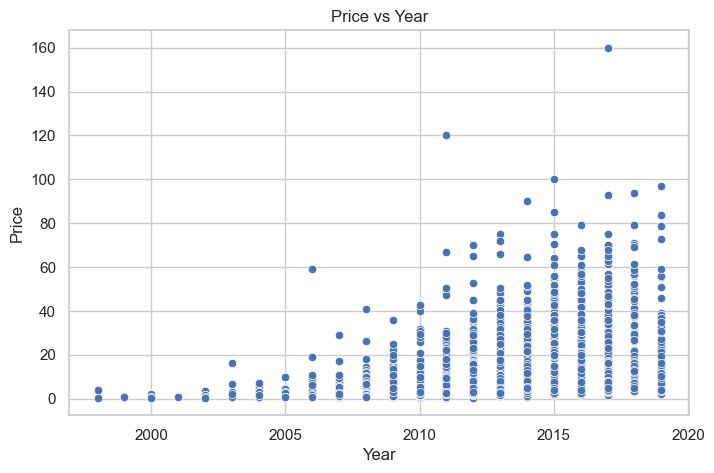

In [ ]:
# Price vs Year
plt.figure(figsize=(8,5))
sns.scatterplot(x="Year", y="Price", data=df)
plt.title("Price vs Year")
plt.show()


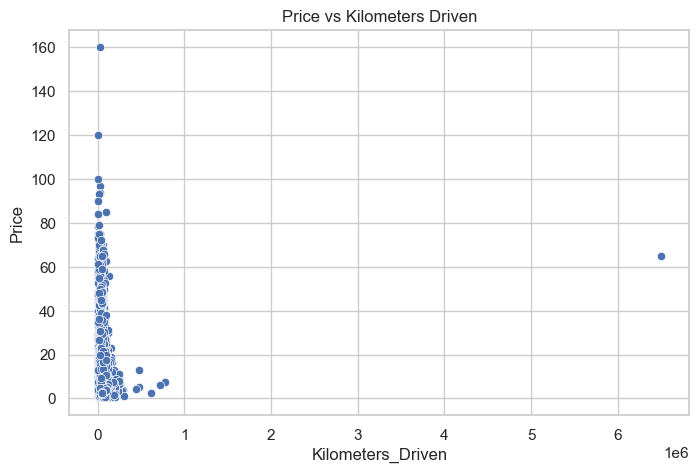

In [ ]:
# Price vs Kilometers Driven
plt.figure(figsize=(8,5))
sns.scatterplot(x="Kilometers_Driven", y="Price", data=df)
plt.title("Price vs Kilometers Driven")
plt.show()


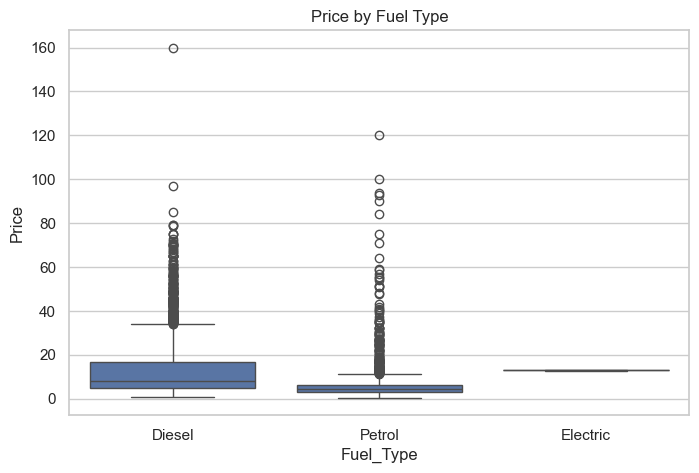

In [ ]:
# Price by Fuel Type
plt.figure(figsize=(8,5))
sns.boxplot(x="Fuel_Type", y="Price", data=df)
plt.title("Price by Fuel Type")
plt.show()


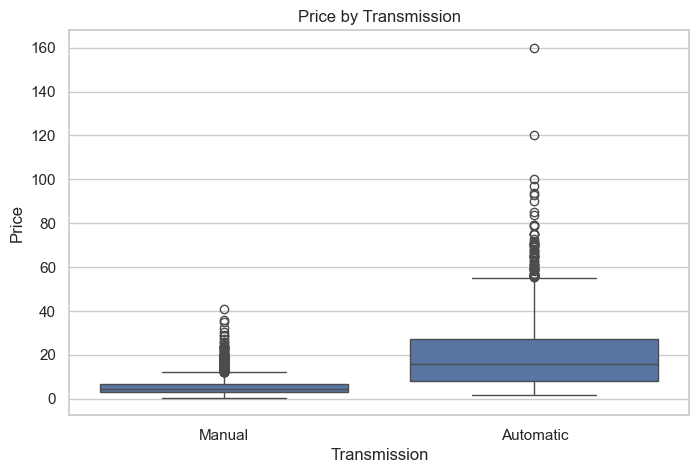

In [ ]:
# Price by Transmission Type
plt.figure(figsize=(8,5))
sns.boxplot(x="Transmission", y="Price", data=df)
plt.title("Price by Transmission")
plt.show()


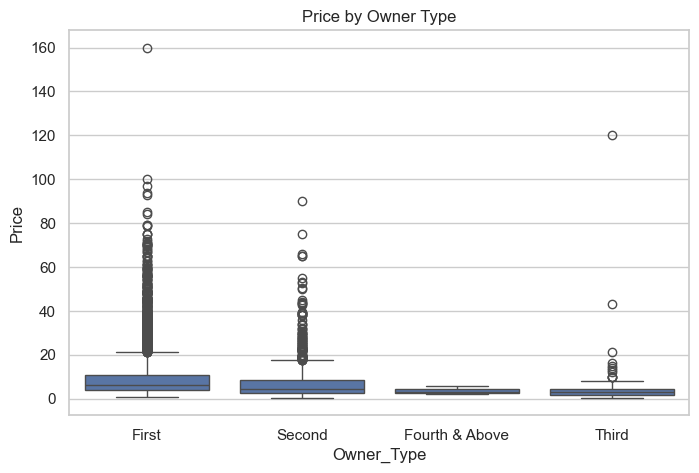

In [ ]:
# Price by Owner Type
plt.figure(figsize=(8,5))
sns.boxplot(x="Owner_Type", y="Price", data=df)
plt.title("Price by Owner Type")
plt.show()


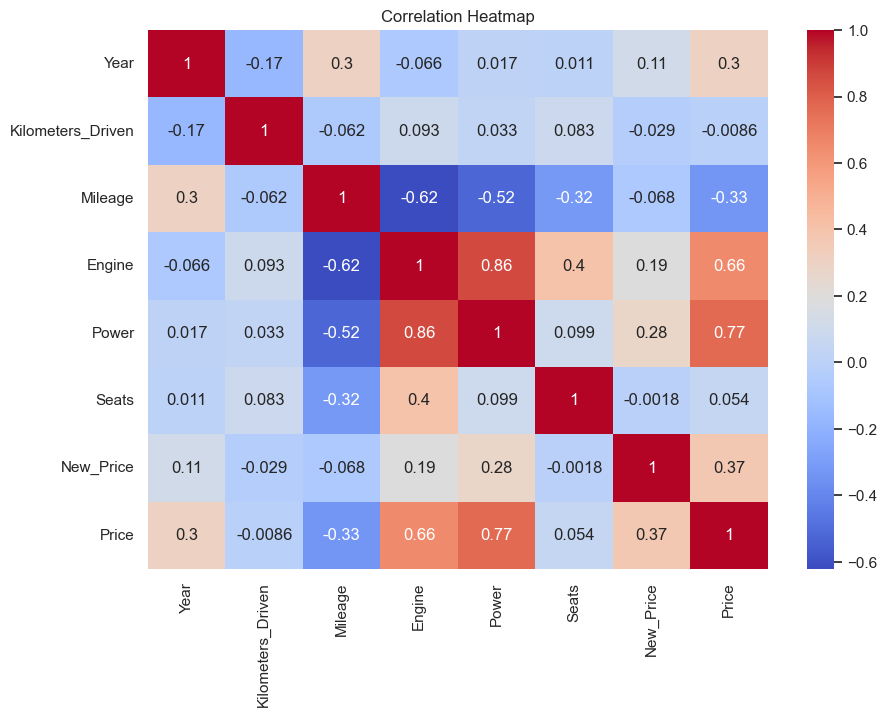

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [32]:
df.to_csv("cleaned_used_car_data.csv", index=False)
